# Med Vision: Chest X Ray Pneumonia Classification

Med Vision is an educational medical imaging project that explores how deep learning models can classify chest X ray images as either normal or pneumonia.

This project uses a public chest X ray dataset to train and evaluate an image classification model. The goal is to understand the basic workflow of medical image AI, including preprocessing, model training, evaluation, and visual interpretation.

This project is not a diagnostic tool and should not be used for medical decision making.

## Project Goals

The goals of this project are to:

1. Load and explore a public chest X ray dataset
2. Preprocess medical images for model training
3. Train a deep learning classifier
4. Evaluate performance using accuracy, precision, recall, F1 score, and a confusion matrix
5. Visualize predictions on sample X ray images
6. Discuss the limitations of medical image classification models

In [1]:
# Core libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Image handling
import cv2
from PIL import Image

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
!pip install kaggle

In [ ]:
from google.colab import files

files.upload()

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key configured successfully.")

Kaggle API key configured successfully.


In [5]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:14<00:00, 18.3MB/s]



In [6]:
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data

print("Dataset downloaded and unzipped.")

Dataset downloaded and unzipped.


In [7]:
base_dir = "/content/chest_xray_data/chest_xray"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

print("Train folders:", os.listdir(train_dir))
print("Validation folders:", os.listdir(val_dir))
print("Test folders:", os.listdir(test_dir))

Train folders: ['NORMAL', 'PNEUMONIA']
Validation folders: ['NORMAL', 'PNEUMONIA']
Test folders: ['NORMAL', 'PNEUMONIA']


## Dataset Exploration

Before training the model, I first checked the structure of the dataset and counted how many images were available in each class. This helps reveal whether the dataset is balanced or imbalanced.

In [8]:
def count_images(folder_path):
    normal_count = len(os.listdir(os.path.join(folder_path, "NORMAL")))
    pneumonia_count = len(os.listdir(os.path.join(folder_path, "PNEUMONIA")))
    return normal_count, pneumonia_count

train_normal, train_pneumonia = count_images(train_dir)
val_normal, val_pneumonia = count_images(val_dir)
test_normal, test_pneumonia = count_images(test_dir)

dataset_counts = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Normal": [train_normal, val_normal, test_normal],
    "Pneumonia": [train_pneumonia, val_pneumonia, test_pneumonia],
    "Total": [
        train_normal + train_pneumonia,
        val_normal + val_pneumonia,
        test_normal + test_pneumonia
    ]
})

dataset_counts

,Split,Normal,Pneumonia,Total
0,Train,1341,3875,5216
1,Validation,8,8,16
2,Test,234,390,624


### Dataset Balance

The dataset contains more pneumonia X rays than normal X rays, especially in the training set. This class imbalance is important because it can affect model performance and may cause the model to favour the majority class.

The validation folder is also very small, with only 16 total images. Because of this, I used a validation split from the training data during model training instead of relying only on the original validation folder.

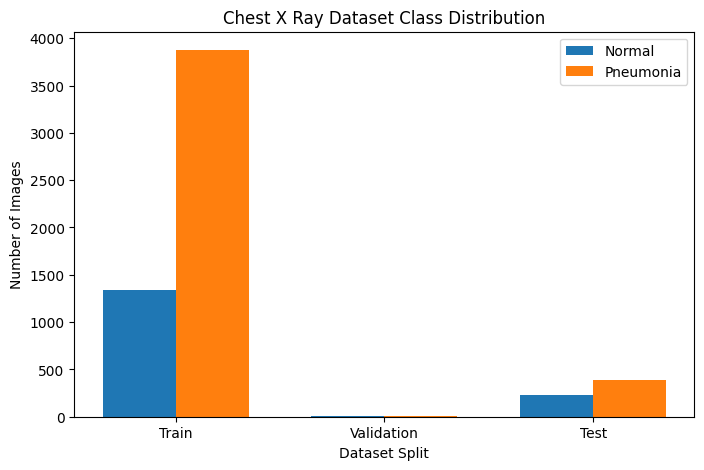

In [9]:
plt.figure(figsize=(8, 5))

x = np.arange(len(dataset_counts["Split"]))
width = 0.35

plt.bar(x - width/2, dataset_counts["Normal"], width, label="Normal")
plt.bar(x + width/2, dataset_counts["Pneumonia"], width, label="Pneumonia")

plt.xticks(x, dataset_counts["Split"])
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.title("Chest X Ray Dataset Class Distribution")
plt.legend()
plt.show()

## Sample X Ray Images

To better understand the dataset, I displayed sample images from both classes. This gives a quick visual sense of the type of images the model will learn from.

In [11]:
def show_sample_images(folder_path, class_name, num_images=5):
    class_folder = os.path.join(folder_path, class_name)
    image_files = os.listdir(class_folder)
    sample_files = random.sample(image_files, num_images)

    plt.figure(figsize=(15, 4))

    for i, image_file in enumerate(sample_files):
        image_path = os.path.join(class_folder, image_file)
        image = Image.open(image_path).convert("L")

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(class_name)
        plt.axis("off")

    plt.show()

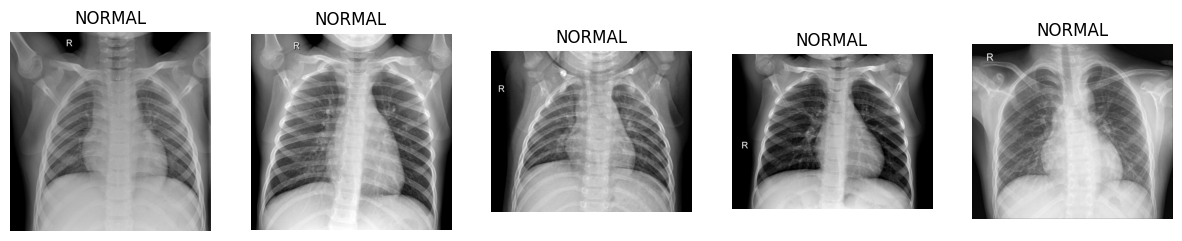

In [12]:
show_sample_images(train_dir, "NORMAL", num_images=5)

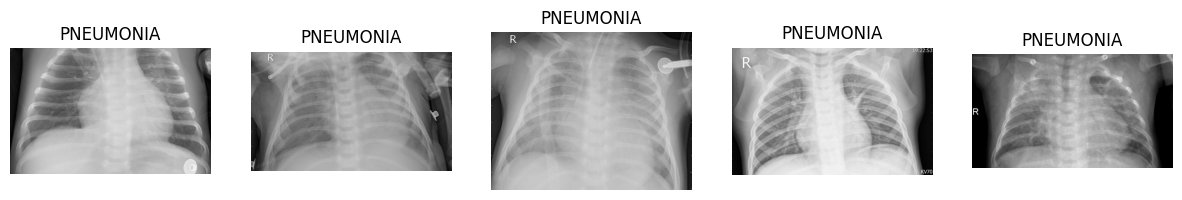

In [13]:
show_sample_images(train_dir, "PNEUMONIA", num_images=5)

## Image Preprocessing

Before training the model, the images need to be resized and normalized. I resized all X ray images to 150 by 150 pixels and scaled pixel values between 0 and 1.

I also used data augmentation on the training images to help the model generalize better.

In [15]:
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [16]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="grayscale",
    subset="training",
    seed=SEED
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="grayscale",
    subset="validation",
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="grayscale",
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [17]:
print("Class labels:", train_generator.class_indices)

Class labels: {'NORMAL': 0, 'PNEUMONIA': 1}


## Model Building

For the first version of Med Vision, I built a convolutional neural network. A CNN is commonly used for image classification because it can learn visual patterns such as edges, textures, shapes, and regions of contrast.

This model is intentionally simple so the project can focus on the full medical imaging workflow: preprocessing, training, evaluation, and interpretation.

In [18]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,801 (18.42 MB)

 Trainable params: 4,828,353 (18.42 MB)

 Non-trainable params: 448 (1.75 KB)

## Model Training

The model was trained using the augmented training images and evaluated on the validation split. Training and validation accuracy were tracked across epochs to observe whether the model was learning effectively or overfitting.

In [19]:
EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 62s 405ms/step - accuracy: 0.8797 - loss: 0.3094 - val_accuracy: 0.7430 - val_loss: 1.9765
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 352ms/step - accuracy: 0.9185 - loss: 0.2045 - val_accuracy: 0.7430 - val_loss: 5.2030
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 44s 338ms/step - accuracy: 0.9272 - loss: 0.1950 - val_accuracy: 0.7430 - val_loss: 5.0829
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 348ms/step - accuracy: 0.9384 - loss: 0.1650 - val_accuracy: 0.7459 - val_loss: 1.8738
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 44s 339ms/step - accuracy: 0.9375 - loss: 0.1667 - val_accuracy: 0.8485 - val_loss: 0.3613
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 347ms/step - accuracy: 0.9434 - loss: 0.1514 - val_accuracy: 0.9166 - val_loss: 0.1953
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 44s 337ms/step - accuracy: 0.9439 - loss: 0.1479 - val_accuracy: 0.9684 - val_loss: 0.1053
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 349ms/step - accuracy: 0.9439 - loss: 0

## Training Performance

After training, I plotted the training and validation accuracy and loss across epochs. These curves help show whether the model improved over time and whether it may be overfitting.

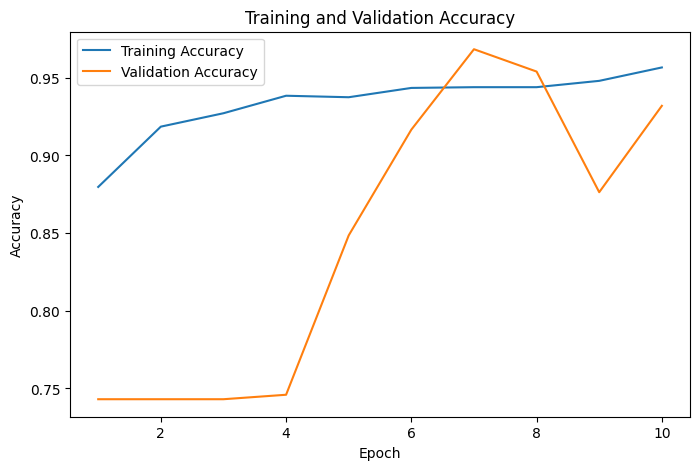

In [20]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

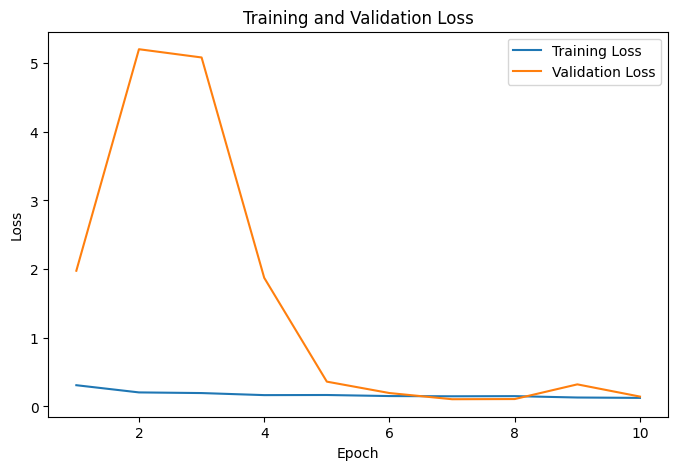

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## Model Evaluation on Test Set

After training, I evaluated the model on the test set. The test set was kept separate from the training and validation data, which makes it useful for estimating how the model performs on unseen images.

In [22]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", round(test_accuracy, 4))
print("Test Loss:", round(test_loss, 4))

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.7388 - loss: 0.8706
Test Accuracy: 0.7388
Test Loss: 0.8706


In [23]:
test_generator.reset()

pred_probs = model.predict(test_generator)
pred_classes = (pred_probs > 0.5).astype("int32").flatten()

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("Prediction probabilities shape:", pred_probs.shape)
print("Predicted classes shape:", pred_classes.shape)
print("True classes shape:", true_classes.shape)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step
Prediction probabilities shape: (624, 1)
Predicted classes shape: (624,)
True classes shape: (624,)


## Classification Report

Accuracy alone does not fully describe model performance, especially when the dataset is imbalanced. Because of this, I also calculated precision, recall, and F1 score for each class.

In [24]:
report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
)

print(report)

              precision    recall  f1-score   support

      NORMAL       1.00      0.30      0.47       234
   PNEUMONIA       0.71      1.00      0.83       390

    accuracy                           0.74       624
   macro avg       0.85      0.65      0.65       624
weighted avg       0.82      0.74      0.69       624



## Confusion Matrix

To better understand the model's mistakes, I created a confusion matrix. This shows how many normal and pneumonia X rays were classified correctly or incorrectly.

<Figure size 600x600 with 0 Axes>

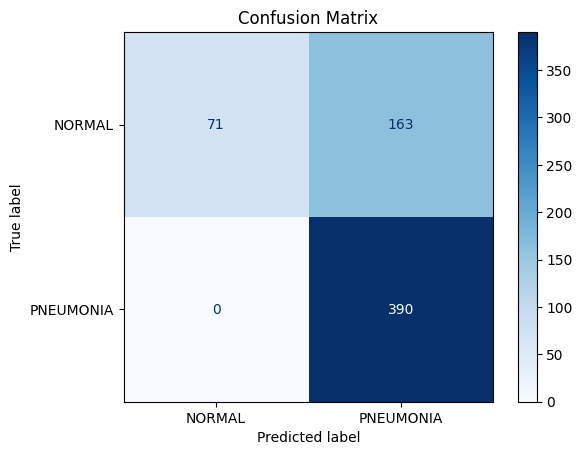

In [25]:
cm = confusion_matrix(true_classes, pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

### Evaluation Interpretation

The model achieved moderate test accuracy, but the classification report and confusion matrix show that performance was not balanced across both classes.

The model detected pneumonia cases very strongly, but it struggled to correctly identify normal X rays. This suggests that the model may be biased toward the pneumonia class, likely because the training dataset contains more pneumonia images than normal images.

Because of this, accuracy alone is not enough to evaluate the model. Recall, precision, F1 score, and the confusion matrix provide a clearer picture of model performance.

## Handling Class Imbalance

Because the training dataset contains more pneumonia images than normal images, I used class weights to give more importance to the minority class during training. This helps reduce bias toward the majority class.

In [26]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

class_weights_dict

{0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}

In [27]:
EPOCHS = 10

history_weighted = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    class_weight=class_weights_dict
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 365ms/step - accuracy: 0.9298 - loss: 0.1794 - val_accuracy: 0.9358 - val_loss: 0.1415
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 352ms/step - accuracy: 0.9485 - loss: 0.1411 - val_accuracy: 0.9559 - val_loss: 0.1039
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 348ms/step - accuracy: 0.9482 - loss: 0.1374 - val_accuracy: 0.9463 - val_loss: 0.1263
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 44s 340ms/step - accuracy: 0.9533 - loss: 0.1289 - val_accuracy: 0.9655 - val_loss: 0.0917
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 44s 336ms/step - accuracy: 0.9497 - loss: 0.1471 - val_accuracy: 0.7929 - val_loss: 0.5925
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 44s 333ms/step - accuracy: 0.9547 - loss: 0.1259 - val_accuracy: 0.9684 - val_loss: 0.0819
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 341ms/step - accuracy: 0.9523 - loss: 0.1333 - val_accuracy: 0.9703 - val_loss: 0.0966
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 341ms/step - accuracy: 0.9533 - loss: 0

## Weighted Model Evaluation

After retraining the model with class weights, I evaluated it again on the test set. The goal was to see whether the model became better at identifying normal X rays while still detecting pneumonia cases well.

In [28]:
weighted_test_loss, weighted_test_accuracy = model.evaluate(test_generator)

print("Weighted Model Test Accuracy:", round(weighted_test_accuracy, 4))
print("Weighted Model Test Loss:", round(weighted_test_loss, 4))

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 238ms/step - accuracy: 0.8766 - loss: 0.3300
Weighted Model Test Accuracy: 0.8766
Weighted Model Test Loss: 0.33


In [29]:
test_generator.reset()

weighted_pred_probs = model.predict(test_generator)
weighted_pred_classes = (weighted_pred_probs > 0.5).astype("int32").flatten()

print("Prediction probabilities shape:", weighted_pred_probs.shape)
print("Predicted classes shape:", weighted_pred_classes.shape)
print("True classes shape:", true_classes.shape)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 316ms/step
Prediction probabilities shape: (624, 1)
Predicted classes shape: (624,)
True classes shape: (624,)


## Weighted Model Classification Report

The weighted model was evaluated using precision, recall, and F1 score. This helps show whether class weighting improved performance across both normal and pneumonia X rays.

In [30]:
weighted_report = classification_report(
    true_classes,
    weighted_pred_classes,
    target_names=class_labels
)

print(weighted_report)

              precision    recall  f1-score   support

      NORMAL       0.96      0.70      0.81       234
   PNEUMONIA       0.85      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624



<Figure size 600x600 with 0 Axes>

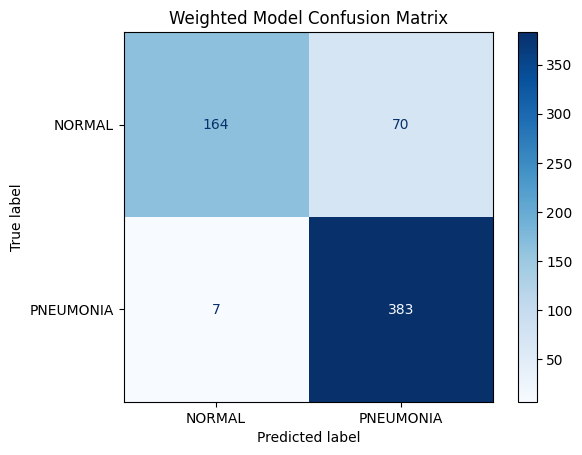

In [31]:
weighted_cm = confusion_matrix(true_classes, weighted_pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=weighted_cm,
    display_labels=class_labels
)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Weighted Model Confusion Matrix")
plt.show()

### Weighted Model Interpretation

After applying class weights, the model became more balanced. The normal recall improved from 0.30 to 0.70, meaning the model became much better at correctly identifying normal X rays.

The pneumonia recall remained very high at 0.98, meaning the model still detected most pneumonia cases. This is important because, in a medical screening context, missing pneumonia cases could be more concerning than falsely flagging normal X rays.

The weighted model achieved an overall test accuracy of 0.88, with a weighted F1 score of 0.87. Compared to the first model, the weighted model provides a stronger and more balanced result.

## Model Comparison

To summarize the impact of class weighting, I compared the first model with the weighted model. This shows how addressing class imbalance improved test performance.

In [32]:
comparison_data = {
    "Model": ["Initial CNN", "Weighted CNN"],
    "Test Accuracy": [0.74, 0.88],
    "Normal Recall": [0.30, 0.70],
    "Pneumonia Recall": [1.00, 0.98],
    "Weighted F1 Score": [0.69, 0.87]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Model,Test Accuracy,Normal Recall,Pneumonia Recall,Weighted F1 Score
0,Initial CNN,0.74,0.3,1.00,0.69
1,Weighted CNN,0.88,0.7,0.98,0.87


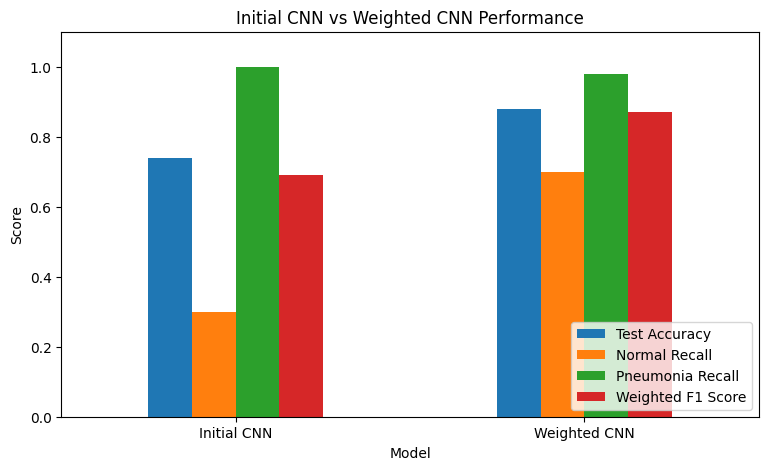

In [33]:
comparison_df.set_index("Model").plot(kind="bar", figsize=(9, 5))

plt.title("Initial CNN vs Weighted CNN Performance")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## Sample Predictions

To make the model results easier to interpret, I displayed sample test images with their true labels, predicted labels, and prediction confidence.

In [35]:
def show_model_predictions(generator, pred_probs, pred_classes, true_classes, num_images=9):
    file_paths = generator.filepaths
    indices = random.sample(range(len(file_paths)), num_images)

    plt.figure(figsize=(12, 12))

    for i, idx in enumerate(indices):
        image_path = file_paths[idx]
        image = Image.open(image_path).convert("L")

        true_label = class_labels[true_classes[idx]]
        predicted_label = class_labels[pred_classes[idx]]
        confidence = pred_probs[idx][0]

        if predicted_label == "NORMAL":
            display_confidence = 1 - confidence
        else:
            display_confidence = confidence

        plt.subplot(3, 3, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(
            f"True: {true_label}\nPredicted: {predicted_label}\nConfidence: {display_confidence:.2f}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

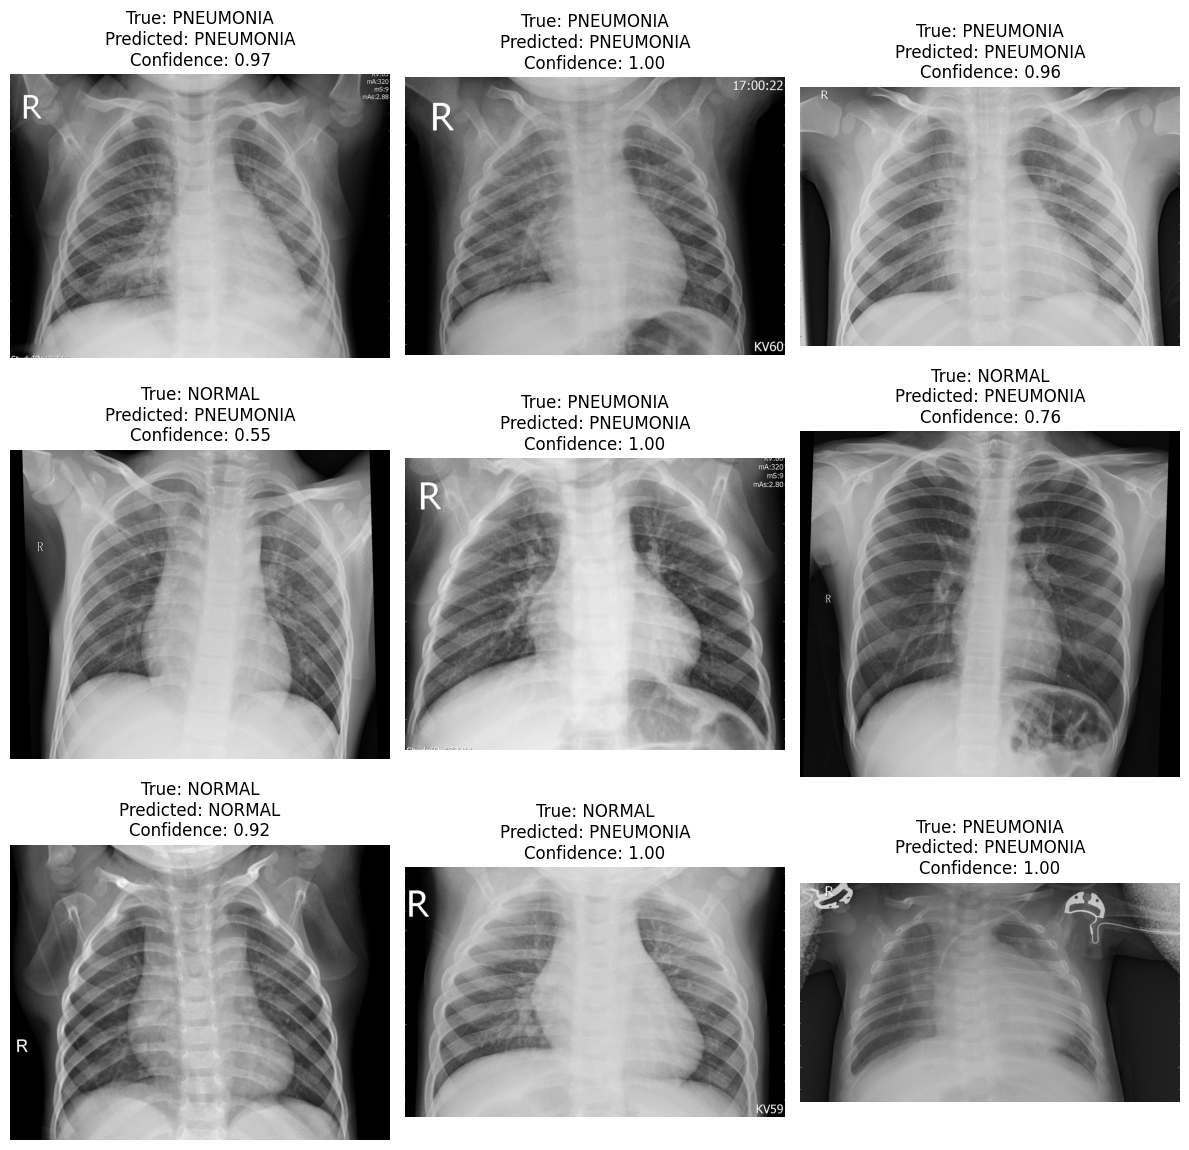

In [36]:
show_model_predictions(
    test_generator,
    weighted_pred_probs,
    weighted_pred_classes,
    true_classes,
    num_images=9
)

### Prediction Interpretation

The sample predictions show how the weighted model performs on individual X ray images. Some predictions are correct with high confidence, while others may be incorrect or uncertain.

This is important because medical AI models should not only be evaluated using summary metrics. Looking at individual examples helps reveal where the model performs well and where it may still make mistakes.

## Grad CAM Visual Explainability

To make the model more interpretable, I used Grad CAM. Grad CAM highlights the regions of an image that most influenced the model's prediction.

This is especially useful in medical imaging projects because it gives a visual explanation of what the model may be focusing on.

In [38]:
import tensorflow.keras.backend as K

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        prediction_score = predictions[:, 0]

    grads = tape.gradient(prediction_score, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)

    if np.max(heatmap) != 0:
        heatmap = heatmap / np.max(heatmap)

    return heatmap

In [39]:
def load_image_for_gradcam(image_path):
    image = Image.open(image_path).convert("L")
    image = image.resize((IMG_WIDTH, IMG_HEIGHT))
    image_array = np.array(image) / 255.0
    image_array = np.expand_dims(image_array, axis=-1)
    image_array = np.expand_dims(image_array, axis=0)
    return image_array

In [40]:
def display_gradcam(image_path, model, last_conv_layer_name):
    img_array = load_image_for_gradcam(image_path)

    prediction_prob = model.predict(img_array, verbose=0)[0][0]
    predicted_class = "PNEUMONIA" if prediction_prob > 0.5 else "NORMAL"
    confidence = prediction_prob if predicted_class == "PNEUMONIA" else 1 - prediction_prob

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    original_image = Image.open(image_path).convert("RGB")
    original_image = original_image.resize((IMG_WIDTH, IMG_HEIGHT))
    original_array = np.array(original_image)

    heatmap_resized = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))
    heatmap_resized = np.uint8(255 * heatmap_resized)

    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed_image = heatmap_colored * 0.4 + original_array
    superimposed_image = np.uint8(superimposed_image)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original_array, cmap="gray")
    plt.title("Original X Ray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_image)
    plt.title(f"Grad CAM\nPrediction: {predicted_class}, Confidence: {confidence:.2f}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [41]:
for layer in model.layers:
    print(layer.name, layer.__class__.__name__)

conv2d Conv2D
batch_normalization BatchNormalization
max_pooling2d MaxPooling2D
conv2d_1 Conv2D
batch_normalization_1 BatchNormalization
max_pooling2d_1 MaxPooling2D
conv2d_2 Conv2D
batch_normalization_2 BatchNormalization
max_pooling2d_2 MaxPooling2D
flatten Flatten
dense Dense
dropout Dropout
dense_1 Dense


In [43]:
dummy_input = np.zeros((1, IMG_HEIGHT, IMG_WIDTH, 1))
_ = model(dummy_input)

print("Model has been called successfully.")

Model has been called successfully.


In [47]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1))
    x = inputs

    last_conv_output = None

    for layer in model.layers:
        x = layer(x)

        if layer.name == last_conv_layer_name:
            last_conv_output = x

    grad_model = tf.keras.models.Model(
        inputs=inputs,
        outputs=[last_conv_output, x]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        prediction_score = predictions[:, 0]

    grads = tape.gradient(prediction_score, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)

    if np.max(heatmap) != 0:
        heatmap = heatmap / np.max(heatmap)

    return heatmap

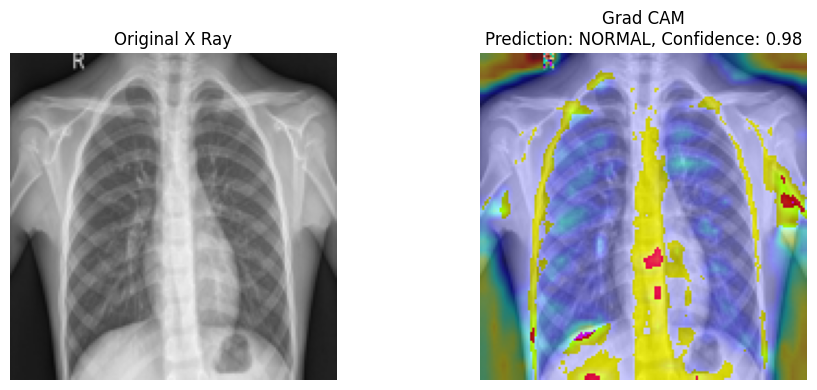

In [48]:
last_conv_layer_name = "conv2d_2"

sample_image_path = test_generator.filepaths[0]

display_gradcam(
    sample_image_path,
    model,
    last_conv_layer_name
)

## Multiple Grad CAM Examples

To further inspect model behaviour, I displayed Grad CAM heatmaps for multiple test images. This helps show whether the model focuses on meaningful regions across different examples.

In [49]:
def display_multiple_gradcams(generator, model, last_conv_layer_name, num_images=6):
    file_paths = generator.filepaths
    indices = random.sample(range(len(file_paths)), num_images)

    plt.figure(figsize=(12, num_images * 3))

    for i, idx in enumerate(indices):
        image_path = file_paths[idx]

        img_array = load_image_for_gradcam(image_path)

        prediction_prob = model.predict(img_array, verbose=0)[0][0]
        predicted_class = "PNEUMONIA" if prediction_prob > 0.5 else "NORMAL"
        confidence = prediction_prob if predicted_class == "PNEUMONIA" else 1 - prediction_prob

        true_class_index = generator.classes[idx]
        true_class = class_labels[true_class_index]

        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

        original_image = Image.open(image_path).convert("RGB")
        original_image = original_image.resize((IMG_WIDTH, IMG_HEIGHT))
        original_array = np.array(original_image)

        heatmap_resized = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))
        heatmap_resized = np.uint8(255 * heatmap_resized)

        heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

        superimposed_image = heatmap_colored * 0.4 + original_array
        superimposed_image = np.uint8(superimposed_image)

        plt.subplot(num_images, 2, 2 * i + 1)
        plt.imshow(original_array, cmap="gray")
        plt.title(f"Original X Ray\nTrue: {true_class}")
        plt.axis("off")

        plt.subplot(num_images, 2, 2 * i + 2)
        plt.imshow(superimposed_image)
        plt.title(
            f"Grad CAM\nPredicted: {predicted_class}, Confidence: {confidence:.2f}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

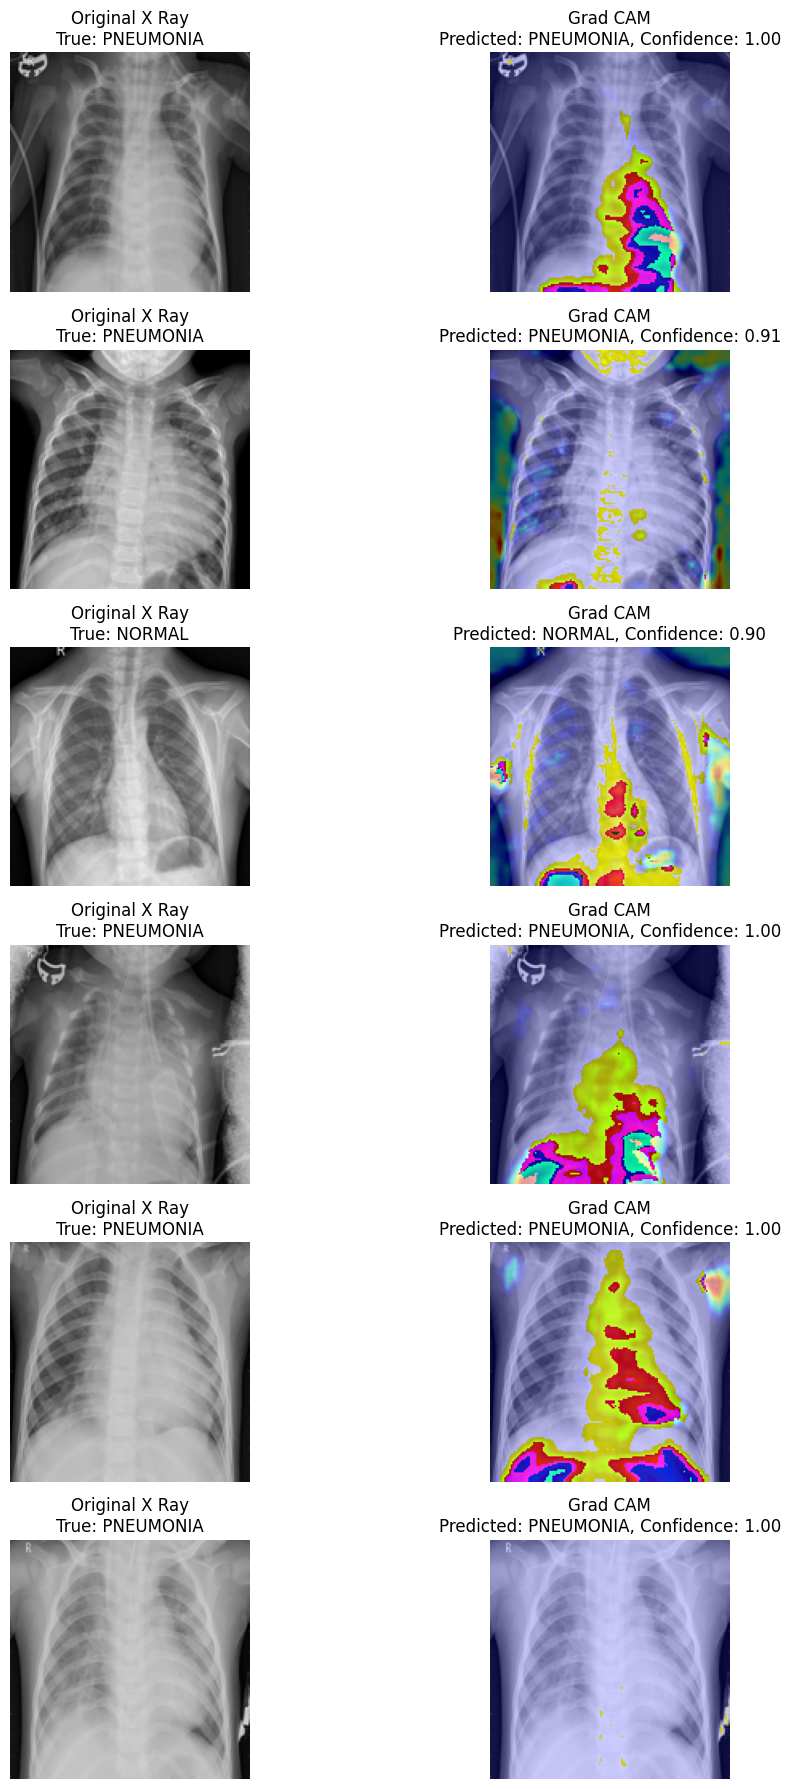

In [50]:
display_multiple_gradcams(
    test_generator,
    model,
    last_conv_layer_name,
    num_images=6
)

### Grad CAM Interpretation

The Grad CAM heatmaps show which regions of the X ray influenced the model's prediction. In some cases, the model appears to focus on lung regions, while in other cases it may also highlight areas outside the lungs.

This is an important limitation. A heatmap does not prove that the model is clinically correct. It only provides a visual clue about what image regions influenced the prediction. For medical use, model outputs would need expert review, external validation, and clinical testing.

## ROC Curve and AUC

To further evaluate the weighted model, I plotted the ROC curve and calculated the AUC score. The ROC curve shows the tradeoff between sensitivity and specificity across different classification thresholds.

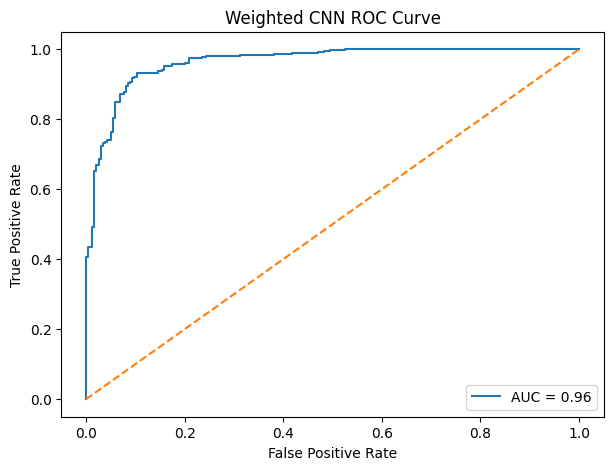

AUC Score: 0.9634


In [53]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(true_classes, weighted_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Weighted CNN ROC Curve")
plt.legend(loc="lower right")
plt.show()

print("AUC Score:", round(roc_auc, 4))

## Threshold Considerations

The model used a default classification threshold of 0.5. This means predictions above 0.5 were classified as pneumonia, while predictions below 0.5 were classified as normal.

In medical screening contexts, the threshold may need to be adjusted depending on the goal. A lower threshold may catch more pneumonia cases but increase false positives. A higher threshold may reduce false positives but risk missing more pneumonia cases.

For this educational project, I kept the default threshold of 0.5, but threshold tuning would be an important next step in a real clinical validation process.

## Future Improvements

Future versions of this project could improve the model and analysis in several ways:

1. Train a transfer learning model such as MobileNetV2, ResNet50, or EfficientNet.
2. Test different classification thresholds to improve the balance between false positives and false negatives.
3. Use external datasets to evaluate generalization across different hospitals and patient populations.
4. Compare model performance against a simpler baseline model.
5. Improve Grad CAM visualization by checking whether highlighted regions align with lung areas.
6. Use better preprocessing methods such as contrast normalization or lung region cropping.
7. Evaluate the model separately on different subgroups if patient metadata is available.

## Limitations and Responsible Use

This project is an educational medical imaging project and is not a diagnostic tool. The model was trained on a public dataset and should not be used for real medical decision making.

Several limitations are important:

1. The dataset contains pediatric chest X rays, so the model may not generalize to adults or other patient populations.
2. The dataset is imbalanced, with more pneumonia images than normal images.
3. The model was trained and tested on one public dataset, not validated across multiple hospitals or imaging systems.
4. Grad CAM heatmaps provide visual clues, but they do not prove that the model is focusing on clinically meaningful regions.
5. Real medical AI systems require expert review, external validation, clinical testing, privacy safeguards, and regulatory approval.

The purpose of this project is to demonstrate a basic medical image classification workflow, including preprocessing, model training, evaluation, class imbalance handling, and explainability.

## Conclusion

Med Vision demonstrates a basic deep learning workflow for chest X ray pneumonia classification. The first CNN model achieved moderate test performance, but evaluation showed that it was biased toward predicting pneumonia.

After applying class weights, the model became more balanced. The weighted CNN improved overall test accuracy from 0.74 to 0.88 and improved normal recall from 0.30 to 0.70 while keeping pneumonia recall high at 0.98.

This project shows why medical AI models should be evaluated using more than accuracy. Precision, recall, F1 score, confusion matrices, and visual explainability tools all provide important context for understanding model behaviour.

Overall, Med Vision is a portfolio project focused on medical imaging, deep learning, responsible AI, and model interpretability.

In [54]:
model.save("medvision_weighted_cnn_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [55]:
from google.colab import files

files.download("medvision_weighted_cnn_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
!rm -f kaggle.json
!rm -f ~/.kaggle/kaggle.json

print("Kaggle API key removed from Colab environment.")

Kaggle API key removed from Colab environment.
